In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("combined_disp.csv")

display(df.head())
print(df.info())
print(df.describe())

,pdb,eigdir,topology_mode,pc_set,sigma,atom_count,protein_residue_count,max_disp_nm,max_atom_index,max_atom_label,mean_disp_nm,p95_disp_nm,p99_disp_nm
0,1a7u,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,PC1,1.0,4290,554,2.584099,702,GLN90:NE2,1.077936,2.395057,2.501110
1,1a7u,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,PC2,1.0,4290,554,1.833725,1876,LYS242:NZ,0.652547,1.608952,1.732532
2,1a7u,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,PC3,1.0,4290,554,1.227172,1024,ASP133:O,0.274537,0.818320,0.994150
3,1a7u,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,"PCs[1,2,3]",1.0,4290,554,3.126662,2143,LYS277:O,1.301506,2.897266,3.025103
4,1a7u,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,PC1,1.0,4290,554,1.665483,1174,ALA154:O,0.389960,1.269816,1.462901


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pdb                    4188 non-null   object 
 1   eigdir                 4188 non-null   object 
 2   topology_mode          4188 non-null   object 
 3   pc_set                 4188 non-null   object 
 4   sigma                  4188 non-null   float64
 5   atom_count             4188 non-null   int64  
 6   protein_residue_count  4188 non-null   int64  
 7   max_disp_nm            4188 non-null   float64
 8   max_atom_index         4188 non-null   int64  
 9   max_atom_label         4188 non-null   object 
 10  mean_disp_nm           4188 non-null   float64
 11  p95_disp_nm            4188 non-null   float64
 12  p99_disp_nm            4188 non-null   float64
dtypes: float64(5), int64(3), object(5)
memory usage: 425.5+ KB
None
        sigma   atom_count  protein_residue_

In [2]:
df.isna().sum()
df.columns
df["pdb"].unique()
df["pdb"].value_counts()

pdb
1a7u    40
1dxx    40
1fe5    40
1fof    40
1m2r    40
        ..
1os5    32
8ifj    32
1rat    20
6gh1     4
6e4d     4
Name: count, Length: 108, dtype: int64

In [3]:
#Filter for the max value to each PDB

df_filtered = df.loc[df.groupby("pdb")["max_disp_nm"].idxmax()].reset_index(drop=True)
display(df_filtered.head())
df_filtered["pdb"].unique()
df_filtered["pdb"].value_counts()

,pdb,eigdir,topology_mode,pc_set,sigma,atom_count,protein_residue_count,max_disp_nm,max_atom_index,max_atom_label,mean_disp_nm,p95_disp_nm,p99_disp_nm
0,1a7u,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,"PCs[1,2,3]",1.0,4290,554,4.555945,702,GLN90:NE2,1.554936,3.960274,4.266058
1,1dxx,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,"PCs[1,2,3]",1.0,3866,478,2.246680,500,THR69:CG2,0.720401,1.872328,2.096766
2,1e65,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,"PCs[1,2,3]",1.0,3896,512,0.627964,309,LYS41:NZ,0.089559,0.168955,0.240310
3,1fe5,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,"PCs[1,2,3]",1.0,898,118,0.628252,870,THR115:CG2,0.078910,0.240634,0.501312
4,1fof,/work001/csongor/boxpred/pca_nma_dot_product/r...,protein_heavy,"PCs[1,2,3]",1.0,3880,492,1.003328,3462,GLU195:OE1,0.073419,0.208984,0.470185


pdb
1a7u    1
1dxx    1
1e65    1
1fe5    1
1fof    1
       ..
8uut    1
8wtr    1
9j5z    1
9jdq    1
9mjl    1
Name: count, Length: 108, dtype: int64

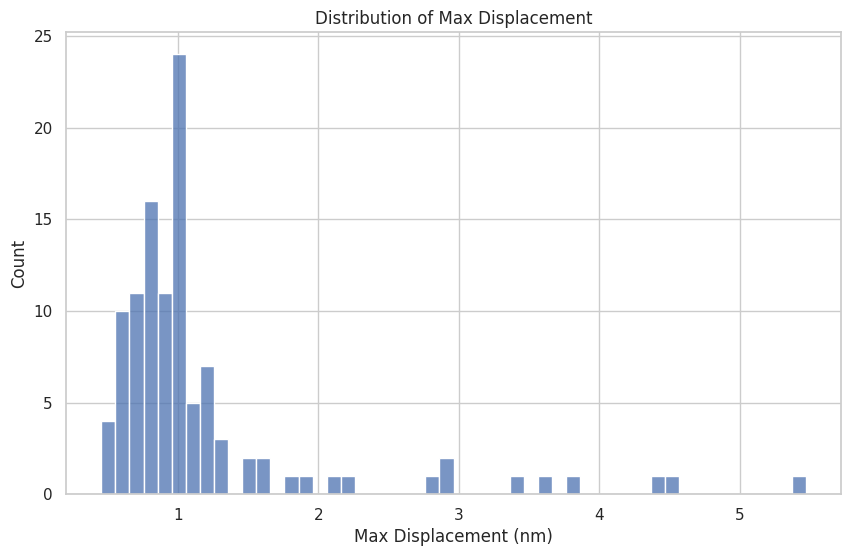

Mean: 1.1901024527146449
Median: 0.9720648194130901
95th percentile: 3.2110281248940336
99th percentile: 4.54393904402127


In [ ]:
#distribution of max_disp_nm
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered["max_disp_nm"], bins=50)
plt.xlabel("Max Displacement (nm)")
plt.ylabel("Count")
plt.title("Distribution of Max Displacement")
plt.show()

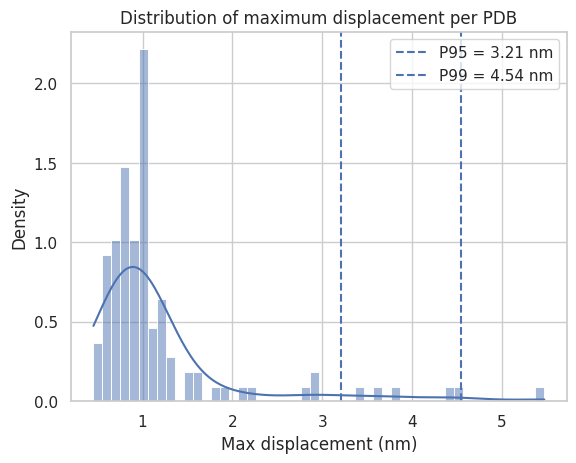

In [16]:
plt.figure()

sns.histplot(df_filtered["max_disp_nm"], bins=50, stat="density", kde=True)

# add percentiles
p95 = df_filtered["max_disp_nm"].quantile(0.95)
p99 = df_filtered["max_disp_nm"].quantile(0.99)

plt.axvline(p95, linestyle="--", label=f"P95 = {p95:.2f} nm")
plt.axvline(p99, linestyle="--", label=f"P99 = {p99:.2f} nm")

plt.xlabel("Max displacement (nm)")
plt.ylabel("Density")
plt.title("Distribution of maximum displacement per PDB")
plt.legend()

plt.show()

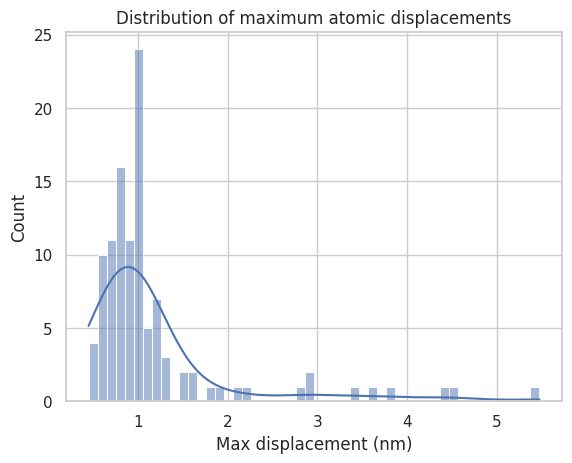

In [6]:
plt.figure()
sns.histplot(df_filtered["max_disp_nm"], bins=50, kde=True)
plt.xlabel("Max displacement (nm)")
plt.ylabel("Count")
plt.title("Distribution of maximum atomic displacements")
plt.show()

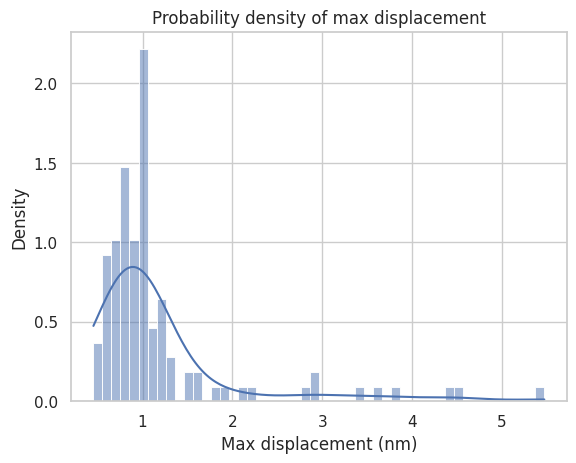

In [23]:
#normalised distribution of max_disp_nm

plt.figure()
sns.histplot(df_filtered["max_disp_nm"], bins=50, stat="density", kde=True)
plt.xlabel("Max displacement (nm)")
plt.ylabel("Density")
plt.title("Probability density of max displacement")
plt.show()

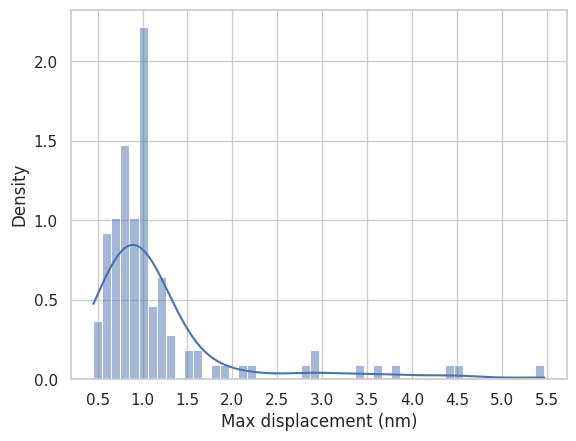

In [28]:
import matplotlib.ticker as mticker

plt.figure()

sns.histplot(df_filtered["max_disp_nm"], bins=50, stat="density", kde=True)

ax = plt.gca()

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
#ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

#ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.xlabel("Max displacement (nm)")
plt.ylabel("Density")

plt.show()

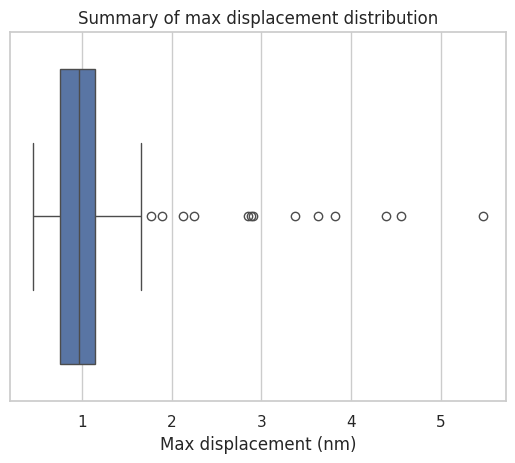

In [8]:
#box plot

plt.figure()
sns.boxplot(x=df_filtered["max_disp_nm"])
plt.xlabel("Max displacement (nm)")
plt.title("Summary of max displacement distribution")
plt.show()

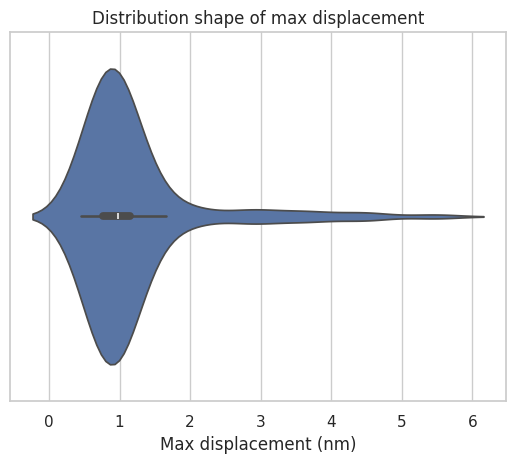

In [12]:
#violin plot

plt.figure()
sns.violinplot(x=df_filtered["max_disp_nm"])
plt.xlabel("Max displacement (nm)")
plt.title("Distribution shape of max displacement")
plt.show()